# **Phần 1: Phân tích Nhật Ký Tìm Kiếm (Search Log) & Tính toán Web Metrics**


## **Cài đặt thư viện và nạp dữ liệu**

Trong thực tế Big Data, dữ liệu Search Log được sinh ra liên tục theo thời gian thực (Đặc trưng Velocity). Ở bài tập này, chúng ta sẽ tạo ra một tập dữ liệu gồm 10,000 bản ghi log để mô phỏng lại hành vi của người dùng trên một trang thương mại điện tử.

**Mô tả đặc trưng dữ liệu**
- `ip_address`: Địa chỉ ip truy cập
- `timestamp`: Thời gian click chuột
- `query`: Truy vấn người dùng
- `landing_page`: Chuyển từ trang nào
- `action`: Hành động của người dùng

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

df = pd.read_csv('web_search_logs.csv')
df

,ip_address,timestamp,query,landing_page,action
0,192.168.1.164,2020-12-23 00:00:00,NaN,/checkout_success,bounce_exit
1,192.168.1.29,2020-12-23 00:00:10,NaN,/home,hover
2,192.168.1.7,2020-12-23 00:00:16,NaN,/home,purchase
3,192.168.1.190,2020-12-23 00:00:15,sạc dự phòng anker,/product_detail,search
4,192.168.1.71,2020-12-23 00:00:47,NaN,/product_detail,hover
...,...,...,...,...,...
9995,192.168.1.177,2020-12-24 17:08:05,NaN,/cart,hover
9996,192.168.1.73,2020-12-24 14:56:08,NaN,/cart,purchase
9997,192.168.1.66,2020-12-24 05:36:34,NaN,/cart,click
9998,192.168.1.203,2020-12-24 01:56:36,NaN,/product_detail,view


**Data Granularity (Độ mịn dữ liệu):** Dữ liệu thô ở mức độ log (từng cú click chuột của từng IP) có độ mịn cao nhất nhưng khó nhìn thấy bức tranh tổng thể. Chúng ta cần tổng hợp (Aggregation) nó về mức độ theo giờ hoặc theo ngày.

In [ ]:
# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('web_search_logs.csv', parse_dates=['timestamp'])

# 2. Thay đổi độ mịn dữ liệu (Granularity): Trích xuất cột Giờ (Hour) từ Timestamp
df['hour'] = df['timestamp'].dt.hour

# 3. Thống kê số lượng tương tác theo từng khung giờ trong ngày
hourly_traffic = df.groupby('hour').size().reset_index(name='total_actions')
print("--- Thống kê lưu lượng truy cập theo giờ ---")
print(hourly_traffic.head())

--- Thống kê lưu lượng truy cập theo giờ ---
   hour  total_actions
0     0            596
1     1            563
2     2            542
3     3            565
4     4            497


## **Bài tập thực hành**

### **Câu 1:**

Dựa vào kiến thức về độ mịn dữ liệu (Data Granularity), hãy lọc ra các bản ghi có hành động là `search`, sau đó thống kê xem trong khung giờ cao điểm (từ 20h đến 22h), 3 từ khóa (`query`) nào được người dùng tìm kiếm nhiều nhất?

In [ ]:
# TODO 1: Lọc df với action == 'search' và hour nằm trong khoảng [20, 21, 22]
# TODO 2: Dùng value_counts() trên cột 'query' và lấy top 3


#### **Đáp án**


In [ ]:
df_new = df.loc[(df['action'] == 'search') & (df['hour'] >= 20) & (df['hour'] <= 22)]
df_new['query'].value_counts().head(3)

,count
query,
tìm kiếm chung,41
sạc dự phòng anker,17
ốp lưng điện thoại,14


### **Câu 2**

Dựa trên tập dữ liệu đã cho, hãy viết code để tính toán hai chỉ số quan trọng sau:

- **Conversion Rate (Tỷ lệ chuyển đổi):** Tỷ lệ người dùng thực hiện hành vi mua hàng (purchase) trên tổng số người dùng truy cập.
  - Conversion Rate (%): Được tính bằng `(Tổng số hành động 'purchase') / (Tổng số hành động trong toàn bộ hệ thống) * 100`.
  
- Bounce Rate (%): Được tính bằng `(Tổng số hành động 'bounce_exit') / (Tổng số hành động trong toàn bộ hệ thống) * 100`.
  - **Bounce Rate (Tỷ lệ thoát):** Tỷ lệ người dùng rời đi ngay từ trang đầu tiên mà không có thêm tương tác nào khác (bounce_exit).


In [ ]:

# TODO 3: Dùng thuộc tính của cột action hoặc hàm value_counts() để lấy số lượng cụ thể từng hành động.

# -------------------

# print(f"Conversion Rate: {total_purchase / total_actions * 100}")
# print(f"Bounce Rate: {df.loc[df['action'] == 'bounce_exit']['action'].count() / total_actions * 100}")

#### **Đáp án**

In [ ]:
total_actions = df['action'].count()
total_purchase = df.loc[df['action'] == 'purchase']['action'].count()

print(f"Conversion Rate: {total_purchase / total_actions * 100}")
print(f"Bounce Rate: {df.loc[df['action'] == 'bounce_exit']['action'].count() / total_actions * 100}")

Conversion Rate: 16.16
Bounce Rate: 17.26


### **Câu 3:**

Nếu hệ thống thương mại điện tử này tăng quy mô lên gấp 1,000 lần (đạt mức vài chục triệu bản ghi log mỗi ngày - chạm ngưỡng đặc trưng Volume của Big Data), việc sử dụng thư viện Pandas chạy trên một máy tính đơn lẻ như hiện tại sẽ gặp phải những hạn chế gì? Giải pháp thay thế là gì?

# **Phần 2: Lập Trình Mô Hình MapReduce Phân Tán Với PySpark**

## **Cài đặt môi trường Apache Spark**

Thao tác này sẽ cấu hình một cụm Spark chạy cục bộ (Local Cluster) ngay trên máy ảo của Colab.

In [ ]:
# Cài đặt PySpark
!pip install pyspark

# Khởi tạo Spark Session - Cửa sổ giao tiếp chính với hệ thống Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Lab2_MapReduce_Spark") \
    .getOrCreate()

# Lấy Spark Context để làm việc với RDD (Tập dữ liệu phân tán)
sc = spark.sparkContext
print(f"Phiên bản Spark hiện tại: {spark.version}")

Phiên bản Spark hiện tại: 4.0.3


## **Tư duy "Chia để trị" (WordCount với RDD)**
- **Shared-nothing Architecture:** Mỗi nút xử lý độc lập phần dữ liệu được phân chia cho nó mà không dùng chung tài nguyên phần cứng.

- **Map Phase:** Nhận một cặp khóa/giá trị thô và sinh ra một cặp khóa/giá trị trung gian.

- Shuffle & Sort: Spark tự động nhóm các giá trị có cùng khóa lại với nhau qua hạ tầng mạng mạng lưới.

- **Reduce Phase:** Gom tụ hoặc tính toán trên tập các giá trị trung gian có cùng khóa để cho ra kết quả cuối cùng.

In [ ]:
# 1. Tạo một tập dữ liệu văn bản thô dạng RDD phân tán
text_data = ["Big Data là dữ liệu lớn", "Hadoop và Spark hỗ trợ xử lý dữ liệu lớn", "Spark xử lý dữ liệu in memory"]
rdd_raw = sc.parallelize(text_data)

# 2. Giai đoạn Map: Tách câu thành từ và chuyển thành cặp (Word, 1)
rdd_words = rdd_raw.flatMap(lambda line: line.split(" "))
rdd_pairs = rdd_words.map(lambda word: (word, 1))

# 3. Giai đoạn Reduce: Cộng tổng các giá trị (Value) có cùng từ khóa (Key)
rdd_counts = rdd_pairs.reduceByKey(lambda a, b: a + b)

# 4. Hành động (Action) để in kết quả ra màn hình
print("--- Kết quả đếm từ bằng mô hình MapReduce ---")
for word, count in rdd_counts.collect():
    print(f"Từ: '{word}' xuất hiện {count} lần")

--- Kết quả đếm từ bằng mô hình MapReduce ---
Từ: 'Big' xuất hiện 1 lần
Từ: 'dữ' xuất hiện 3 lần
Từ: 'liệu' xuất hiện 3 lần
Từ: 'lớn' xuất hiện 2 lần
Từ: 'Hadoop' xuất hiện 1 lần
Từ: 'hỗ' xuất hiện 1 lần
Từ: 'trợ' xuất hiện 1 lần
Từ: 'xử' xuất hiện 2 lần
Từ: 'lý' xuất hiện 2 lần
Từ: 'memory' xuất hiện 1 lần
Từ: 'Data' xuất hiện 1 lần
Từ: 'là' xuất hiện 1 lần
Từ: 'và' xuất hiện 1 lần
Từ: 'Spark' xuất hiện 2 lần
Từ: 'in' xuất hiện 1 lần


## **Bài tập thực hành**

Giả sử nhận được một file log dữ liệu doanh thu bán hàng quốc tế thô của năm 2014. Nhiệm vụ là áp dụng mô hình **MapReduce** của Spark để lọc ra các giao dịch hợp lệ và tính tổng doanh thu thu được theo từng Quốc gia.

In [ ]:
# Khởi tạo dữ liệu doanh thu thô (Sinh viên chạy ô này để tạo dữ liệu)
sales_raw_data = [
    "VN,2014,1500", "US,2014,4000", "JP,2013,2200",
    "VN,2014,3000", "US,2013,1200", "JP,2014,5000",
    "VN,2015,2500", "US,2014,3500", "KR,2014,1800"
]
rdd_sales = sc.parallelize(sales_raw_data)

### **Câu 1:**

### **Thiết kế tầng Map (Map Phase)**
Mỗi dòng dữ liệu đang ở dạng chuỗi `"Quốc_Gia,Năm,Doanh_Thu"`.  Hãy viết hàm xử lý để:

1. Tách chuỗi dữ liệu bằng dấu phẩy ,.

2. Lọc chỉ lấy các bản ghi thuộc năm 2014.

3. Chuyển đổi dữ liệu sau lọc thành cấu trúc cặp Key-Value dạng: (Quốc_Gia, Doanh_Thu) (Lưu ý: Doanh thu phải chuyển về kiểu số nguyên int).


In [ ]:
# TODO 4: Dùng rdd_sales.map() kết hợp hàm split(',') và cấu trúc điều kiện hoặc dùng bộ lọc .filter()
def process_line(line):
    parts = line.split(',') # Tách chuỗi (1. )
    # Thực hiện kiểm tra năm 2014 tại đây và return kết quả
    pass

# rdd_map_result = ...

#### **Đáp án**

In [ ]:
# TODO 4: Dùng rdd_sales.map() kết hợp hàm split(',') và cấu trúc điều kiện
def process_line(line):
    parts = line.split(',') # Tách chuỗi dữ liệu bằng dấu phẩy

    # parts[0]: Mã QG, parts[1]: Năm, parts[2]: Doanh thu
    year = int(parts[1])

    # Kiểm tra điều kiện năm 2014
    if year == 2014:
        country_code = parts[0]
        revenue = float(parts[2])
        return (country_code, revenue) # Trả về dạng (Key, Value) luôn để tiện cho reduceByKey
    else:
        return None # Trả về None nếu không phải năm 2014

# Thực hiện map dữ liệu qua hàm process_line
rdd_mapped = rdd_sales.map(process_line)

# Dùng .filter() để loại bỏ các giá trị None (các năm không phải 2014)
rdd_map_result = rdd_mapped.filter(lambda x: x is not None)

# Kiểm tra kết quả thu được
print(rdd_map_result.collect())

[('VN', 1500.0), ('US', 4000.0), ('VN', 3000.0), ('JP', 5000.0), ('US', 3500.0), ('KR', 1800.0)]


### **Câu 2:**

### **Thiết kế tầng Reduce (Reduce Phase)**
Sử dụng kết quả `rdd_map_result` thu được từ `Câu 1`,  hãy áp dụng một phép toán thu gọn RDD thích hợp để cộng tổng doanh thu của từng Quốc gia trong năm 2014. In kết quả cuối cùng ra màn hình.


In [ ]:
# TODO 5: Dùng hàm .reduceByKey() để gộp các doanh thu có cùng mã Quốc gia.

#### **Đáp án**

In [ ]:
# TODO 5: Dùng hàm .reduceByKey() để gộp các doanh thu có cùng mã Quốc gia.
rdd_total_revenue = rdd_map_result.reduceByKey(lambda a, b: a + b)

# Thu thập kết quả và in ra màn hình
final_results = rdd_total_revenue.collect()

print("--- TỔNG DOANH THU THEO QUỐC GIA NĂM 2014 ---")
for country, revenue in final_results:
    print(f"Quốc gia: {country} | Tổng doanh thu: {revenue:,.1f}")

--- TỔNG DOANH THU THEO QUỐC GIA NĂM 2014 ---
Quốc gia: JP | Tổng doanh thu: 5,000.0
Quốc gia: VN | Tổng doanh thu: 4,500.0
Quốc gia: US | Tổng doanh thu: 7,500.0
Quốc gia: KR | Tổng doanh thu: 1,800.0


# **Phần 3: Phân Tích Cấu Trúc Đồ Thị Mạng Xã Hội (SNA)**


## **Cài đặt các thư viện xử lý và trực quan hóa đồ thị**

Trong Python, `NetworkX` là thư viện mã nguồn mở mạnh mẽ nhất chuyên dùng để tính toán các đặc trưng hình học của đồ thị (Social Network Analysis - SNA). Chúng ta sẽ kết hợp với `Matplotlib` để vẽ lại bản đồ mạng lưới.

In [ ]:
# Cài đặt hoặc import các thư viện có sẵn trên Colab
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

## **Khởi tạo mạng lưới và tìm chỉ số trung tâm**

- **Nodes (Nút / Đỉnh):** Đại diện cho các đối tượng trong mạng xã hội (ví dụ: Tài khoản người dùng, Trang fanpage).

- **Edges (Cạnh / Liên kết):** Đại diện cho mối quan hệ giữa các đối tượng (ví dụ: Kết bạn, Theo dõi, Tương tác).

- **Degree Centrality (Chỉ số trung tâm bậc):** Số lượng liên kết trực tiếp của một nút. Nút nào có chỉ số này cao nhất chính là các đầu mối thông tin (Hubs/Influencers) tuân theo quy luật phân phối lũy thừa (Power Law).

--- Số lượng liên kết trực tiếp của từng cá nhân ---
Người dùng 'An': có 3 bạn chung trực tiếp.
Người dùng 'Bình': có 2 bạn chung trực tiếp.
Người dùng 'Cường': có 3 bạn chung trực tiếp.
Người dùng 'Dũng': có 2 bạn chung trực tiếp.
Người dùng 'Hoa': có 2 bạn chung trực tiếp.


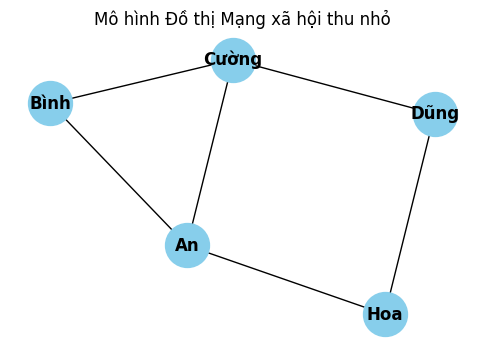

In [ ]:
# 1. Khởi tạo một đồ thị vô hướng rỗng
G_sample = nx.Graph()

# 2. Thêm các mối quan hệ bạn bè mẫu (Đoạn mã giả lập mạng lưới nội bộ)
relationships = [
    ("An", "Bình"), ("An", "Cường"), ("Bình", "Cường"),
    ("Cường", "Dũng"), ("Dũng", "Hoa"), ("Hoa", "An")
]
G_sample.add_edges_from(relationships)

# 3. Tính toán Degree Centrality cho từng người
degrees = dict(G_sample.degree())
print("--- Số lượng liên kết trực tiếp của từng cá nhân ---")
for person, count in degrees.items():
    print(f"Người dùng '{person}': có {count} bạn chung trực tiếp.")

# 4. Trực quan hóa đồ thị ra màn hình
plt.figure(figsize=(6, 4))
nx.draw_networkx(G_sample, node_color='skyblue', node_size=1000, font_weight='bold')
plt.title("Mô hình Đồ thị Mạng xã hội thu nhỏ")
plt.axis('off')
plt.show()

## **Bài tập thực hành**

Giả sử cung cấp dữ liệu tương tác từ một nhóm cộng đồng mạng xã hội gồm các cặp ID tương tác với nhau (người này theo dõi người kia). Đóng vai trò là một nhà phân tích dữ liệu lớn để tìm ra các tài khoản quyền lực nhất trong mạng lưới này.

In [ ]:
# Khởi tạo tập dữ liệu tương tác thô (Sinh viên chạy ô này để nạp dữ liệu)
social_data = {
    'User_A': ['KOL_A', 'KOL_A', 'KOL_B', 'User_C', 'User_D', 'User_E', 'User_F', 'User_G', 'KOL_A', 'KOL_B', 'User_C'],
    'User_B': ['User_C', 'User_D', 'User_E', 'KOL_A', 'KOL_A', 'KOL_B', 'KOL_A', 'KOL_A', 'KOL_B', 'User_D', 'User_F']
}
df_social = pd.DataFrame(social_data)
df_social.head()

,User_A,User_B
0,KOL_A,User_C
1,KOL_A,User_D
2,KOL_B,User_E
3,User_C,KOL_A
4,User_D,KOL_A


### **Câu 1:**

### **Chuyển đổi dữ liệu bảng thành Cấu trúc Đồ thị (Graph Object)**

Hãy viết mã nguồn để:

- Khởi tạo một đối tượng đồ thị mới tên là G_social bằng thư viện networkx.

- Duyệt qua từng dòng của DataFrame df_social (hoặc chuyển đổi trực tiếp) để nạp toàn bộ các cặp quan hệ giữa User_A và User_B thành các Cạnh (edges) của đồ thị

In [ ]:
# TODO 6: Khởi tạo G_social = nx.Graph()
# Có thể dùng hàm nx.from_pandas_edgelist(df_social, source='User_A', target='User_B') để làm nhanh.

G_social = ...

# Kiểm tra số lượng Nút và Cạnh sau khi nạp
# print(f"Số lượng tài khoản (Nodes): {G_social.number_of_nodes()}")
# print(f"Số lượng liên kết (Edges): {G_social.number_of_edges()}")

#### **Đáp án**

In [ ]:
G_social = nx.from_pandas_edgelist(df_social, source='User_A', target='User_B')

# Kiểm tra số lượng Nút và Cạnh sau khi nạp
print(f"Số lượng tài khoản (Nodes): {G_social.number_of_nodes()}")
print(f"Số lượng liên kết (Edges): {G_social.number_of_edges()}")

Số lượng tài khoản (Nodes): 7
Số lượng liên kết (Edges): 8


### **Câu 2:**

### **Xác định KOLs và Trực quan hóa cấu trúc mạng lưới**
1. Sử dụng hàm thích hợp của networkx để tính toán chỉ số kết nối (Degree) hoặc chỉ số trung tâm bậc (nx.degree_centrality). Hãy tìm ra tài khoản nào có sức ảnh hưởng lớn nhất mạng lưới.

2. Vẽ sơ đồ mạng lưới này với kích thước của các nút tỷ lệ thuận với số lượng liên kết của chúng (nút nào nhiều liên kết thì vẽ to hơn).

In [ ]:
# TODO 7: Tìm tài khoản có độ lớn degree cao nhất
# TODO 8: Sử dụng nx.draw_networkx() và truyền mảng kích thước vào tham số node_size

#### **Đáp án**


Tài khoản có nhiều liên kết nhất: KOL_A với 5 liên kết.


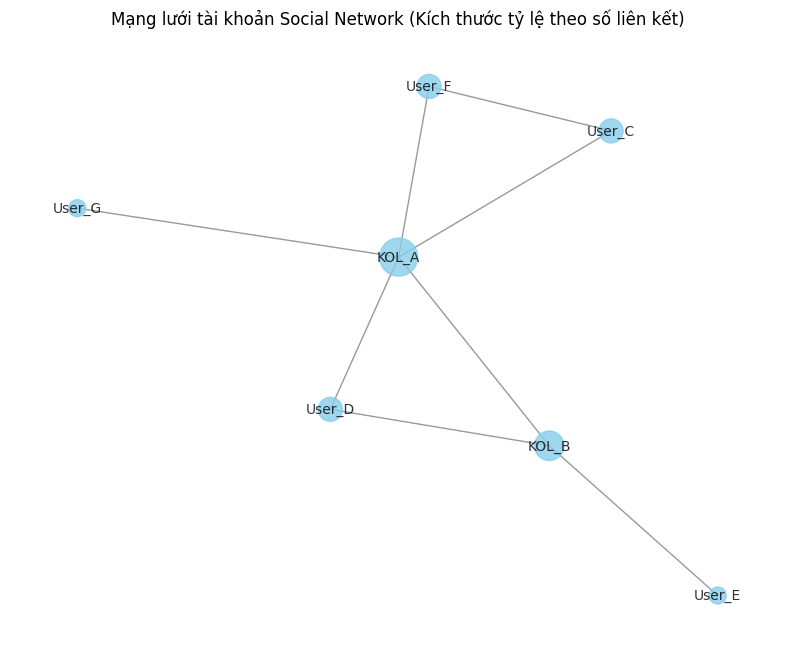

In [ ]:
# TODO 7: Tìm tài khoản có độ lớn degree cao nhất

# Lấy danh sách bậc (degree) của tất cả các nút: dạng [(User, số_bạn_bè), ...]
degrees = dict(G_social.degree())

# Tìm nút có degree lớn nhất
most_connected_user = max(degrees, key=degrees.get)
max_degree = degrees[most_connected_user]

print(f"Tài khoản có nhiều liên kết nhất: {most_connected_user} với {max_degree} liên kết.")


# TODO 8: Sử dụng nx.draw_networkx() và truyền mảng kích thước vào tham số node_size

# Tạo một mảng kích thước nút dựa trên độ lớn degree của từng nút
# Nhân thêm một hệ số (ví dụ: * 100 hoặc * 200) để các nút hiển thị rõ ràng hơn trên hình
node_sizes = [degrees[node] * 150 for node in G_social.nodes()]

# Thiết lập kích thước khung hình vẽ
plt.figure(figsize=(10, 8))

# Vẽ đồ thị với tham số node_size động
nx.draw_networkx(
    G_social,
    node_size=node_sizes,        # Truyền mảng kích thước nút vào đây
    node_color='skyblue',        # Màu sắc của nút
    with_labels=True,            # Hiển thị tên tài khoản trên nút
    font_size=10,                # Cỡ chữ của nhãn
    edge_color='gray',           # Màu đường nối
    alpha=0.8                    # Độ trong suốt để dễ nhìn khi các nút đè lên nhau
)

plt.title("Mạng lưới tài khoản Social Network (Kích thước tỷ lệ theo số liên kết)")
plt.axis('off') # Ẩn trục tọa độ x, y
plt.show()

# **Phần 4: Khai Phá Văn Bản & Phân Tích Cảm Xúc (Sentiment Analysis)**

## **Cài đặt thư viện Tiền xử lý Ngôn ngữ tự nhiên (NLP)**
Trong bài tập này, ngoài thư viện học máy phổ thông `scikit-learn`, chúng ta sẽ sử dụng thêm `underthesea` – một thư viện NLP chuyên dụng cho tiếng Việt để hỗ trợ tách từ (Tokenization)

In [ ]:
# Cài đặt thư viện underthesea chuyên xử lý tiếng Việt
!pip install underthesea

import pandas as pd
import numpy as np
import re
from underthesea import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

## **Làm sạch dữ liệu nhiễu (Veracity)**

- **Dữ liệu phi cấu trúc (Unstructured Data):** Chiếm tới 95% tổng lượng dữ liệu lớn toàn cầu, ví dụ rõ nhất là văn bản (bình luận, bài đăng mạng xã hội).

- **Thách thức Veracity:** Dữ liệu người dùng viết trên mạng xã hội chứa rất nhiều "rác" (Ký tự đặc biệt, viết tắt, từ lóng). Hệ thống bắt buộc phải tiền xử lý (Preprocessing) trước khi đưa vào mô hình phân tích.


In [ ]:
def clean_text(text):
    # 1. Chuyển về chữ thường
    text = text.lower()
    # 2. Xóa các ký tự đặc biệt, chỉ giữ lại chữ cái và khoảng trắng
    text = re.sub(r'[^\w\s]', '', text)
    # 3. Tách từ tiếng Việt (Ví dụ: "dữ liệu lớn" -> "dữ_liệu lớn")
    text = word_tokenize(text, format="text")
    return text

# Chạy thử nghiệm hàm làm sạch
text_sample = "Sản phẩm này xài OK lắm luôn!!! Sẽ ủng hộ tiếp :D"
print(f"Văn bản gốc: {text_sample}")
print(f"Văn bản sau làm sạch: {clean_text(text_sample)}")

Văn bản gốc: Sản phẩm này xài OK lắm luôn!!! Sẽ ủng hộ tiếp :D
Văn bản sau làm sạch: sản_phẩm này xài ok lắm luôn sẽ ủng_hộ tiếp d


## **Bài tập thực hành**

Giả sử hệ thống thu thập dữ liệu di động (Mobile Analytics) đem về một danh sách các câu đánh giá phản hồi (Reviews) của khách hàng về một ứng dụng điện thoại. Dữ liệu này đang bị nhiễu và chưa được phân loại.

In [ ]:
# Khởi tạo tập dữ liệu bình luận thô (Sinh viên chạy ô này để nạp dữ liệu)
raw_reviews = [
    {"review": "Ứng dụng chạy mượt, giao diện đẹp quá trời vote 5 sao!!!", "sentiment": 1}, # 1 là Tích cực
    {"review": "App gì mà lag vcl, cứ vào là bị văng ra bực mình ghê á.", "sentiment": 0},   # 0 là Tiêu cực
    {"review": "Dịch vụ chăm sóc khách hàng rất tốt, hỗ trợ nhanh chóng.", "sentiment": 1},
    {"review": "Quá thất vọng!! Cập nhật xong lỗi không đăng nhập được nữa.", "sentiment": 0},
    {"review": "Xài cũng tạm ổn nhưng cần cải tiến thêm nhiều tính năng.", "sentiment": 1},
    {"review": "Hàng lừa đảo, nạp tiền vô xong bị khóa tài khoản luôn, né gấp mn ơi!!", "sentiment": 0}
]
df_reviews = pd.DataFrame(raw_reviews)
df_reviews.head()

,review,sentiment
0,"Ứng dụng chạy mượt, giao diện đẹp quá trời vot...",1
1,"App gì mà lag vcl, cứ vào là bị văng ra bực mì...",0
2,"Dịch vụ chăm sóc khách hàng rất tốt, hỗ trợ nh...",1
3,Quá thất vọng!! Cập nhật xong lỗi không đăng n...,0
4,Xài cũng tạm ổn nhưng cần cải tiến thêm nhiều ...,1


### **Câu 1:**

### **Tiến hành làm sạch toàn bộ tập dữ liệu**

Hãy áp dụng hàm `clean_text` đã được hướng dẫn ở Mục 2 để xử lý toàn bộ các câu bình luận trong cột review của `df_reviews`
. Lưu kết quả sau khi làm sạch vào một cột mới tên là `cleaned_review`.

In [ ]:
# TODO 9: Sử dụng hàm .apply() của Pandas DataFrame trên cột 'review'

df_reviews['cleaned_review'] = ...
# =================================

# Kiểm tra kết quả sau khi xử lý
df_reviews[['review', 'cleaned_review', 'sentiment']]

,review,cleaned_review,sentiment
0,"Ứng dụng chạy mượt, giao diện đẹp quá trời vot...",Ellipsis,1
1,"App gì mà lag vcl, cứ vào là bị văng ra bực mì...",Ellipsis,0
2,"Dịch vụ chăm sóc khách hàng rất tốt, hỗ trợ nh...",Ellipsis,1
3,Quá thất vọng!! Cập nhật xong lỗi không đăng n...,Ellipsis,0
4,Xài cũng tạm ổn nhưng cần cải tiến thêm nhiều ...,Ellipsis,1
5,"Hàng lừa đảo, nạp tiền vô xong bị khóa tài kho...",Ellipsis,0


#### **Đáp án**

In [ ]:
df_reviews['cleaned_review'] = df_reviews['review'].apply(clean_text)

# Kiểm tra kết quả sau khi xử lý
df_reviews[['review', 'cleaned_review', 'sentiment']]

,review,cleaned_review,sentiment
0,"Ứng dụng chạy mượt, giao diện đẹp quá trời vot...",ứng_dụng chạy mượt giao_diện đẹp quá trời vote...,1
1,"App gì mà lag vcl, cứ vào là bị văng ra bực mì...",app gì mà lag vcl cứ vào là bị văng ra bực_mìn...,0
2,"Dịch vụ chăm sóc khách hàng rất tốt, hỗ trợ nh...",dịch_vụ chăm_sóc khách_hàng rất tốt hỗ_trợ nha...,1
3,Quá thất vọng!! Cập nhật xong lỗi không đăng n...,quá thất_vọng cập_nhật xong lỗi không đăng_nhậ...,0
4,Xài cũng tạm ổn nhưng cần cải tiến thêm nhiều ...,xài cũng tạm ổn nhưng cần cải_tiến thêm nhiều ...,1
5,"Hàng lừa đảo, nạp tiền vô xong bị khóa tài kho...",hàng lừa_đảo nạp tiền vô xong bị khóa tài_khoả...,0


### **Câu 2:**

### **Biến đổi văn bản thành Vector và Huấn luyện mô hình phân loại**
Để máy tính hiểu được văn bản, chúng ta phải chuyển chuỗi ký tự thành ma trận số lượng hóa bằng kỹ thuật `TF-IDF (TfidfVectorizer)`. Hãy hoàn thiện đoạn code dưới đây để:

1. Biến đổi dữ liệu ở cột `cleaned_review` thành ma trận đặc trưng `X`.

2. Gán nhãn mục tiêu `y` từ cột `sentiment`.

3. Huấn luyện một mô hình Naive Bayes (MultinomialNB) để phân loại cảm xúc.

In [ ]:
# Khởi tạo bộ biến đổi vector TF-IDF
vectorizer = TfidfVectorizer()

# TODO 10: Trích xuất đặc trưng bằng vectorizer.fit_transform() trên cột cleaned_review
X = ...
y = df_reviews['sentiment']

# TODO 11: Khởi tạo mô hình Naive Bayes và huấn luyện bằng hàm .fit(X, y)
model = MultinomialNB()
# model.fit(...)

# =================================

# Dự đoán thử nghiệm một câu mới dựa trên mô hình đã học
test_comment = ["Ứng dụng này hay quá"]
test_cleaned = [clean_text(test_comment[0])]
test_vector = vectorizer.transform(test_cleaned)
prediction = model.predict(test_vector)

print(f"Kết quả dự đoán cho câu '{test_comment[0]}': {'Tích cực' if prediction[0] == 1 else 'Tiêu cực'}")

NotFittedError: The TF-IDF vectorizer is not fitted

#### **Đáp án**


In [ ]:
# Khởi tạo bộ biến đổi vector TF-IDF
vectorizer = TfidfVectorizer()

# ==========================================
# TODO 10: Trích xuất đặc trưng bằng vectorizer.fit_transform() trên cột cleaned_review
# ==========================================
X = vectorizer.fit_transform(df_reviews['cleaned_review'])
y = df_reviews['sentiment']

# ==========================================
# TODO 11: Khởi tạo mô hình Naive Bayes và huấn luyện bằng hàm .fit(X, y)
# ==========================================
model = MultinomialNB()
model.fit(X, y)

# ==========================================

# Dự đoán thử nghiệm một câu mới dựa trên mô hình đã học
test_comment = ["Thất vọng"]
test_cleaned = [clean_text(test_comment[0])]  # Đảm bảo câu test cũng được làm sạch giống tập train
test_vector = vectorizer.transform(test_cleaned) # Chỉ dùng .transform(), không dùng fit_transform ở đây
prediction = model.predict(test_vector)

print(f"Kết quả dự đoán cho câu '{test_comment[0]}': {'Tích cực' if prediction[0] == 1 else 'Tiêu cực'}")

Kết quả dự đoán cho câu 'Thất vọng': Tiêu cực
